# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing(1).csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?


--------------------------------------------------
x(GrLivArea) 평균: 1515.4637
y(SalePrice) 평균: 180921.1959
기울기 beta1: 107.1304
절편 beta0: 18569.0259
회귀식: SalePrice = 18569.03 + 107.13 * GrLivArea
GrLivArea=1500 예측 가격: 179264.56
--------------------------------------------------


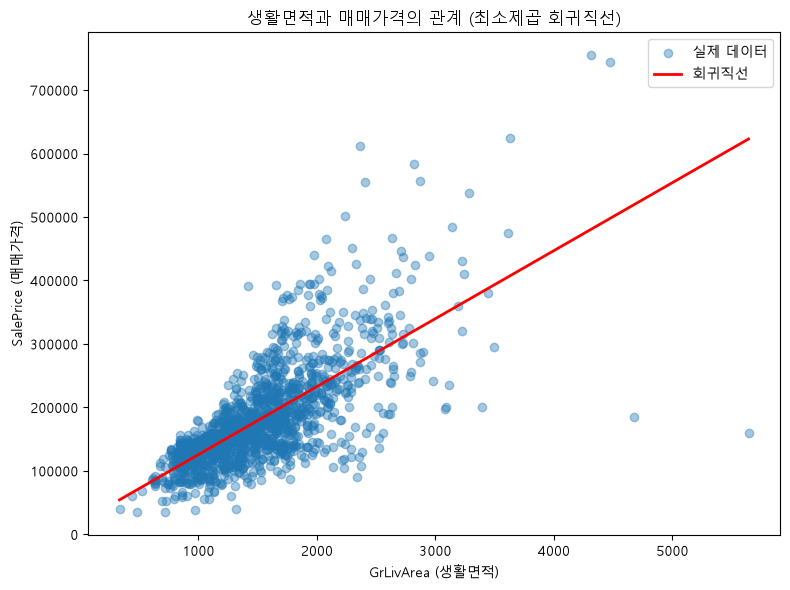

In [3]:
# 여기에 코드를 작성하세요.
plt.rcParams['font.family'] = 'Malgun Gothic'
# ------------------------------
# 1. 결측치 제거 후 분석용 데이터 생성
# ------------------------------
reg_data = df[['GrLivArea', 'SalePrice']].dropna()
x = reg_data['GrLivArea'].to_numpy(dtype=float)
y = reg_data['SalePrice'].to_numpy(dtype=float)

# ------------------------------
# 2. x, y 평균 계산
# ------------------------------
x_mean = x.mean()
y_mean = y.mean()

# ------------------------------
# 3. 최소제곱법으로 beta1(기울기), beta0(절편) 계산
# ------------------------------
beta1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta0 = y_mean - beta1 * x_mean

# ------------------------------
# 4. 회귀식 출력 및 예측
# ------------------------------
target_area = 1500
predicted_price_1500 = beta0 + beta1 * target_area

print("-" * 50)
print(f"x(GrLivArea) 평균: {x_mean:.4f}")
print(f"y(SalePrice) 평균: {y_mean:.4f}")
print(f"기울기 beta1: {beta1:.4f}")
print(f"절편 beta0: {beta0:.4f}")
print(f"회귀식: SalePrice = {beta0:.2f} + {beta1:.2f} * GrLivArea")
print(f"GrLivArea=1500 예측 가격: {predicted_price_1500:.2f}")
print("-" * 50)

# ------------------------------
# 5. 산점도 + 회귀직선 시각화
# ------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, label='실제 데이터')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta0 + beta1 * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label='회귀직선')

plt.xlabel('GrLivArea (생활면적)')
plt.ylabel('SalePrice (매매가격)')
plt.title('생활면적과 매매가격의 관계 (최소제곱 회귀직선)')
plt.legend()
plt.tight_layout()
plt.show()

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
<br> -> 생활면적이 1단위 증가할 때 마다 모델이 예측하는 매매가격이 평균적으로 약 107.13만큼 증가한다는 의미

- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
<br> -> 생활면적이 0일 때 예측가격 약 18,569를 의미한다.
<br> -> 면적이 0인 주택은 관측 범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야 한다.

- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
<br> -> 실제값과 예측값 차이인 잔차를 제곱해서 모두 더한 sse값이 가장 작아지는 기울기와 절편을 선택한다.

---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?


--------------------------------------------------
SSE (오차제곱합): 4,584,171,086,113.13
SST (전체제곱합): 9,207,911,334,609.98
R^2 (결정계수): 0.5021
잔차 평균: 0.0000
MAE (평균절대잔차): 37,638.73
--------------------------------------------------


C:\Users\hasoo\AppData\Local\Temp\ipykernel_18516\722280639.py:33: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\DS_practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


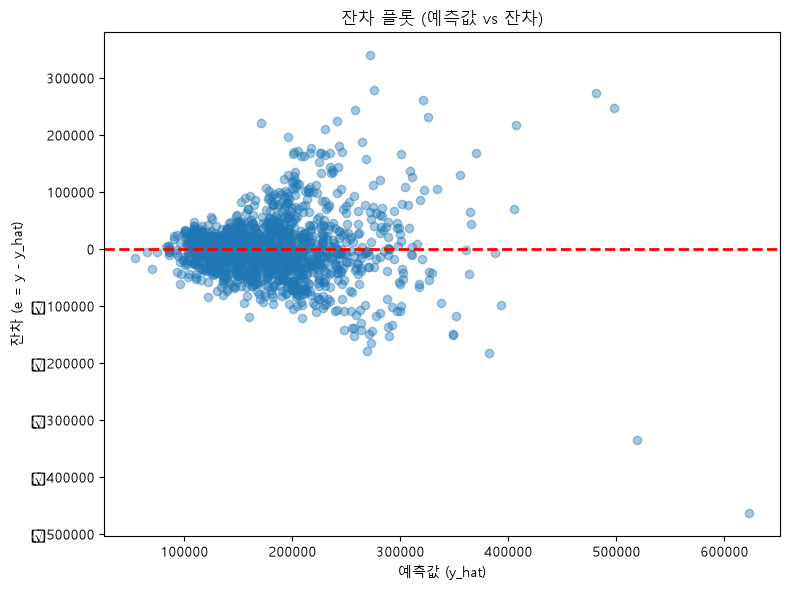

--------------------------------------------------
절대잔차가 가장 큰 관측치의 GrLivArea: 5642.00
실제가격: 160,000.00
예측가격: 622,998.51
잔차: -462,998.51
--------------------------------------------------


In [4]:
# 여기에 코드를 작성하세요.
y_pred = beta0 + beta1 * x
residuals = y - y_pred

sse =np.sum(residuals **2 )
sst = np.sum((y-y_mean)**2)
r_squared = 1 - sse/sst
residual_mean = residuals.mean()
mae = np.mean(np.abs(residuals))

max_error_idx = np.argmax(np.abs(residuals))

# ------------------------------
# 4. 결과 출력
# ------------------------------
print("-" * 50)
print(f"SSE (오차제곱합): {sse:,.2f}")
print(f"SST (전체제곱합): {sst:,.2f}")
print(f"R^2 (결정계수): {r_squared:.4f}")
print(f"잔차 평균: {residual_mean:.4f}")
print(f"MAE (평균절대잔차): {mae:,.2f}")
print("-" * 50)

# ------------------------------
# 5. 잔차 플롯 (예측값 vs 잔차)
# ------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linewidth=2, linestyle='--')
plt.xlabel('예측값 (y_hat)')
plt.ylabel('잔차 (e = y - y_hat)')
plt.title('잔차 플롯 (예측값 vs 잔차)')
plt.tight_layout()
plt.show()

# ------------------------------
# 6. 절대잔차가 가장 큰 관측치 출력
# ------------------------------
max_error_idx = np.argmax(np.abs(residuals))

print("-" * 50)
print(f"절대잔차가 가장 큰 관측치의 GrLivArea: {x[max_error_idx]:.2f}")
print(f"실제가격: {y[max_error_idx]:,.2f}")
print(f"예측가격: {y_pred[max_error_idx]:,.2f}")
print(f"잔차: {residuals[max_error_idx]:,.2f}")
print("-" * 50)

- $R^2$은 이 모델에서 무엇을 의미하나요?
<br> -> 현재 데이터에서 매매가격 전체 변동의 약 50.2%를 생활면적과의 선형회귀 모델이 설명한다는 의미

- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
<br> -> 아닙니다. 양의 잔차와 음의 잔차가 상쇄될 수 있다. 잔차의 크기와 패턴 파악이 추가적으로 필요하다.

- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
<br> -> 높은 예측가격 구간에서 잔차의 퍼짐이 커지는 경향과 회귀선에서 매우 멀리 떨어진 관측치가 보인다.

- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?
<br> -> 생활면적과 가격의 양의 관계 및 약 절반의 변동성을 설명하지만, 나머지 약 49.8%는 설명하지 못했다.
<br> -> 오차의 퍼짐과 극단값도 차이가 컸다.
<br> -> 기본 모델로 모델링을 진행할 수 있다는 것을 확인할 수 있다.

---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


기울기: 1375.3734679368924
절편: -2530308.2457323573

[모델 적합도]
SSE: 6690269293939.84
SST: 9207911334609.98
R^2: 0.2734

[2000년 건축 주택 예측 매매가격]
예측 SalePrice: 220,438.69


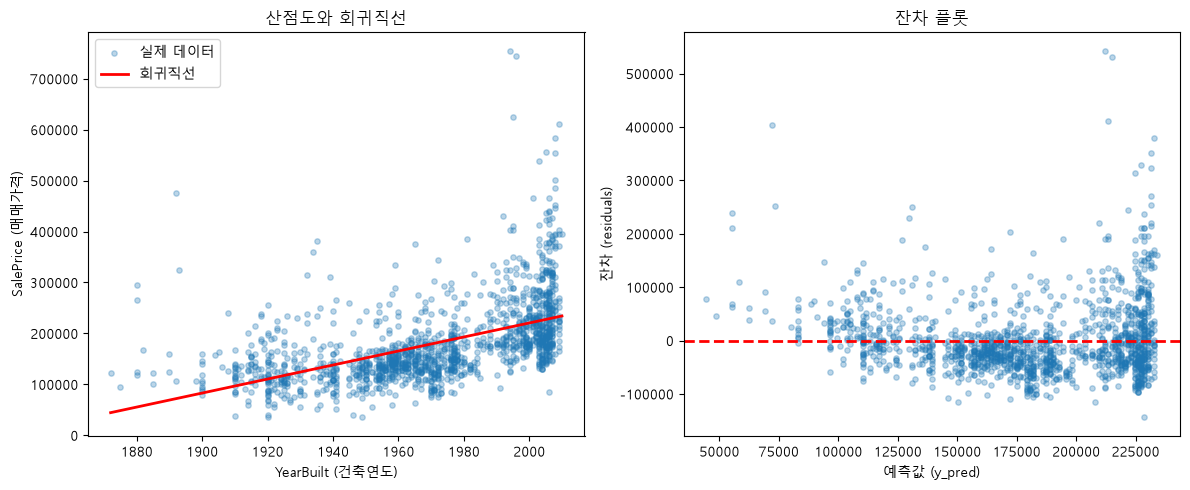

In [8]:
# 여기에 코드를 작성하세요.
x = df['YearBuilt']
y = df['SalePrice']

# 1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
x_mean = x.mean()
y_mean = y.mean()

Sxy = ((x - x_mean) * (y - y_mean)).sum() # x와 y의 공분산
Sxx = ((x - x_mean) ** 2).sum() # x 자체의 흩어짐 정도

# 기울기와 절편 계산
slope = Sxy / Sxx # 기울기  
intercept = y_mean - slope * x_mean # 
print(f'기울기: {slope}')
print(f'절편: {intercept}')

# 2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
y_pred = intercept + slope * x     # 회귀직선으로 계산한 예측값
residuals = y - y_pred             # 잔차 = 실제값 - 예측값

SSE = (residuals ** 2).sum()               # 잔차 제곱합 (모델이 설명 못한 부분)
SST = ((y - y_mean) ** 2).sum()            # 전체 변동 (y가 원래 가진 흩어짐)
R2 = 1 - SSE / SST                          # 설명력

print('\n[모델 적합도]')
print(f'SSE: {SSE:.2f}')
print(f'SST: {SST:.2f}')
print(f'R^2: {R2:.4f}')

# 3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
pred_2000 = intercept + slope * 2000

print('\n[2000년 건축 주택 예측 매매가격]')
print(f'예측 SalePrice: {pred_2000:,.2f}')

# 4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) 산점도 + 회귀직선
axes[0].scatter(x, y, alpha=0.3, s=15, label='실제 데이터')
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='회귀직선')
axes[0].set_xlabel('YearBuilt (건축연도)')
axes[0].set_ylabel('SalePrice (매매가격)')
axes[0].set_title('산점도와 회귀직선')
axes[0].legend()

# (2) 잔차 플롯
axes[1].scatter(y_pred, residuals, alpha=0.3, s=15)
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('예측값 (y_pred)')
axes[1].set_ylabel('잔차 (residuals)')
axes[1].set_title('잔차 플롯')

plt.tight_layout()
plt.show()


# 5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.
- 기울기와 절편은 각각 무엇을 의미하나요?
- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.
---------------------------------------------------------------------------
[결론]
기울기는 건축 연도가 1년 늘어날 때마다 매매가격이  평균적으로 약 1,375달러 증가한다는 뜻이다. 절편(약 -2,530,308)은 수학적으로 x=0일 때의 예측값으로 실제로는 존재할 수 없는 연도여서 데이터에서 해석상 의미를 갖지 않는다. 결정계수 R^2의 값은 0.2734로 모델의 설명력은 높지 않다고 볼 수 있다. 잔차 플롯을 보면 건축연도가 최근일수록 잔차의 흩어짐이 커지는 부채꼴 형태가 나타나낟. 이는 오래된 주택에 대한 예측은 비교적 안정적이지만 최근 지어진 주택에 대한 예측은 오차가 더 클 수 있음을 뜻한다. 이 모델은 설명력이 낮고, 잔차의 흩어짐이 연도에 따라 달라지는 현상을 보이는 문제도 있다. 개선 방향으로는 다른 변수들을 포함하는 다중회귀모델을 고려할 수 있다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
